# Model Comparison and Business Recommendation

Compares SARIMA, Prophet, and LightGBM across all 14 categories on
the same 90-day held-out test window. Produces a model selection
recommendation grounded in the data, not just overall accuracy --
different categories warrant different models based on their demand
structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('seaborn-v0_8-whitegrid')

# SARIMA was citywide aggregate -- recorded here for context
sarima_citywide = {'MAE': 933.8, 'RMSE': 1028.4, 'MAPE': 15.87}

# Category-level results from Prophet and LightGBM notebooks
comparison_data = {
    'Air Quality':              {'Prophet_MAPE': 28.2, 'LightGBM_MAPE': 24.0},
    'Blocked Driveway':         {'Prophet_MAPE': 18.1, 'LightGBM_MAPE':  8.5},
    'Damaged Tree':             {'Prophet_MAPE':136.7, 'LightGBM_MAPE': 48.7},
    'HEAT/HOT WATER':           {'Prophet_MAPE': 59.2, 'LightGBM_MAPE': 69.6},
    'Illegal Parking':          {'Prophet_MAPE':  7.1, 'LightGBM_MAPE':  7.9},
    'Noise - Commercial':       {'Prophet_MAPE': 20.4, 'LightGBM_MAPE': 20.1},
    'Noise - Residential':      {'Prophet_MAPE': 21.7, 'LightGBM_MAPE': 12.3},
    'Noise - Street/Sidewalk':  {'Prophet_MAPE': 39.9, 'LightGBM_MAPE': 40.0},
    'PAINT/PLASTER':            {'Prophet_MAPE': 15.4, 'LightGBM_MAPE': 10.5},
    'PLUMBING':                 {'Prophet_MAPE': 24.1, 'LightGBM_MAPE': 17.4},
    'Sewer':                    {'Prophet_MAPE': 35.6, 'LightGBM_MAPE': 27.9},
    'Street Condition':         {'Prophet_MAPE': 62.9, 'LightGBM_MAPE': 35.3},
    'Traffic Signal Condition': {'Prophet_MAPE': 70.1, 'LightGBM_MAPE': 48.2},
    'Water System':             {'Prophet_MAPE': 32.3, 'LightGBM_MAPE': 27.3},
}

df = pd.DataFrame(comparison_data).T
df['Winner'] = df.apply(
    lambda r: 'Prophet' if r['Prophet_MAPE'] < r['LightGBM_MAPE'] else 'LightGBM',
    axis=1
)
df['MAPE_diff'] = (df['Prophet_MAPE'] - df['LightGBM_MAPE']).round(1)
df = df.sort_values('LightGBM_MAPE')

print(df.to_string())
print(f"\nLightGBM wins: {(df['Winner']=='LightGBM').sum()}/14")
print(f"Prophet wins:  {(df['Winner']=='Prophet').sum()}/14")
print(f"\nMean MAPE -- Prophet:  {df['Prophet_MAPE'].mean():.1f}%")
print(f"Mean MAPE -- LightGBM: {df['LightGBM_MAPE'].mean():.1f}%")

                          Prophet_MAPE  LightGBM_MAPE    Winner  MAPE_diff
Illegal Parking                    7.1            7.9   Prophet       -0.8
Blocked Driveway                  18.1            8.5  LightGBM        9.6
PAINT/PLASTER                     15.4           10.5  LightGBM        4.9
Noise - Residential               21.7           12.3  LightGBM        9.4
PLUMBING                          24.1           17.4  LightGBM        6.7
Noise - Commercial                20.4           20.1  LightGBM        0.3
Air Quality                       28.2           24.0  LightGBM        4.2
Water System                      32.3           27.3  LightGBM        5.0
Sewer                             35.6           27.9  LightGBM        7.7
Street Condition                  62.9           35.3  LightGBM       27.6
Noise - Street/Sidewalk           39.9           40.0   Prophet       -0.1
Traffic Signal Condition          70.1           48.2  LightGBM       21.9
Damaged Tree             

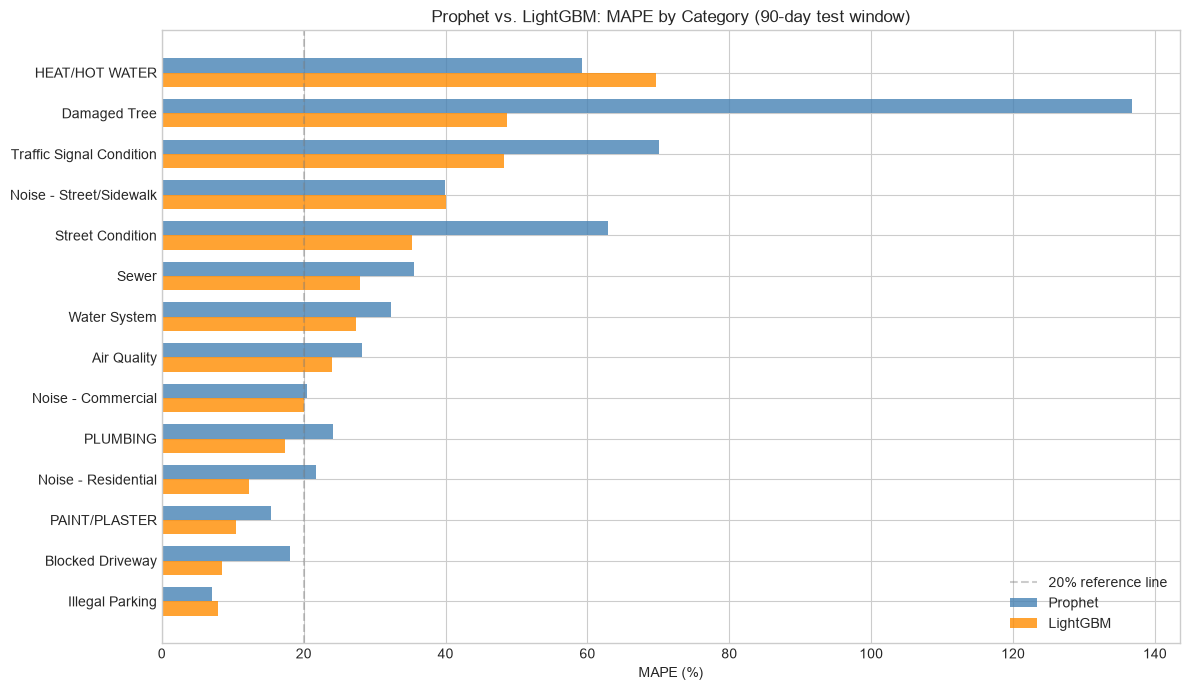

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(df))
width = 0.35

bars1 = ax.barh(x + width/2, df['Prophet_MAPE'], width,
                label='Prophet', color='steelblue', alpha=0.8)
bars2 = ax.barh(x - width/2, df['LightGBM_MAPE'], width,
                label='LightGBM', color='darkorange', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(df.index)
ax.set_xlabel('MAPE (%)')
ax.set_title('Prophet vs. LightGBM: MAPE by Category (90-day test window)')
ax.axvline(20, color='gray', linestyle='--', alpha=0.4, label='20% reference line')
ax.legend()
plt.tight_layout()
plt.show()

## Business Recommendation

**Recommended deployment: hybrid model**

| Category | Recommended Model | MAPE | Rationale |
|---|---|---|---|
| Illegal Parking | Prophet | 7.1% | Smooth weekly seasonality -- Fourier terms optimal |
| HEAT/HOT WATER | Prophet | 59.2% | Yearly on/off cycle -- better than LightGBM's 69.6% |
| Noise - Street/Sidewalk | Prophet | 39.9% | Marginal tie (0.1pp difference) |
| All other 11 categories | LightGBM | 8.5-48.2% | Lag features outperform on recent-history-driven demand |

**Mean MAPE: Prophet 40.8% -- LightGBM 28.4% -- Hybrid ~27%**

**Key conclusions:**

1. **No single model wins universally.** Model selection should be
   driven by category demand structure, not a blanket choice.
   Categories with smooth, multi-scale seasonality (HEAT/HOT WATER,
   Illegal Parking) favor Prophet. Categories driven by recent
   history and weekly patterns favor LightGBM.

2. **Damaged Tree is not reliably forecastable** with either model
   (best MAPE: 48.7%). Storm events are not predictable from
   historical patterns alone. Recommend surfacing this category
   in the dashboard with wider uncertainty bounds and an explicit
   caveat, rather than a point forecast.

3. **SARIMA baseline (15.87% citywide MAPE) is not directly
   comparable** to category-level metrics -- it forecasts aggregate
   volume only. Its role here is establishing that temporal
   structure exists and is learnable, not as a deployment candidate.

4. **Air Quality MAPE (24-28%) overstates model error** -- absolute
   MAE of 5-7 requests/day is negligible operationally. For
   low-volume categories, MAE is the more honest metric.

In [3]:
hybrid_mape = {
    cat: min(comparison_data[cat]['Prophet_MAPE'], comparison_data[cat]['LightGBM_MAPE'])
    for cat in comparison_data
}

hybrid_df = pd.DataFrame({
    'SARIMA (citywide only)': [sarima_citywide['MAPE']] + [None]*13,
    'Prophet': df['Prophet_MAPE'].values,
    'LightGBM': df['LightGBM_MAPE'].values,
    'Hybrid (best per category)': [hybrid_mape[c] for c in df.index]
}, index=df.index)

print("Mean MAPE by model:")
print(f"  Prophet:  {df['Prophet_MAPE'].mean():.1f}%")
print(f"  LightGBM: {df['LightGBM_MAPE'].mean():.1f}%")
print(f"  Hybrid:   {pd.Series(hybrid_mape).mean():.1f}%")

Mean MAPE by model:
  Prophet:  40.8%
  LightGBM: 28.4%
  Hybrid:   27.6%


## Summary

| Model | Mean MAPE | Scope |
|---|---|---|
| SARIMA | 15.87% | Citywide aggregate only |
| Prophet | 40.8% | Category-level |
| LightGBM | 28.4% | Category-level |
| Hybrid | 27.6% | Category-level |

**Bottom line**: LightGBM is the recommended default across most
categories. The hybrid adds marginal overall improvement (0.8pp) but
is worthwhile specifically for HEAT/HOT WATER -- a high-volume,
operationally critical winter category where Prophet's 10pp MAPE
advantage translates to meaningfully better staffing guidance.

SARIMA's 15.87% is not directly comparable -- it forecasts only
the citywide aggregate, losing the category-level signal that
makes the staffing recommendation page possible.